In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
from tqdm import tqdm
import seaborn as sns
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [2]:
plt.style.use('default')

In [ ]:
dataset_dir = "ZPD_Final"

In [4]:
unique_classes = os.listdir(dataset_dir)

In [5]:
n_images = {}

for unique_class in unique_classes:
    class_dir = os.path.join(dataset_dir, unique_class)
    n_images[unique_class] = len(os.listdir(class_dir))

In [6]:
n_images

{'u': 105, 'i': 105, 'a': 103, 'o': 103, 'none': 110, 'e': 103, 'y': 106}

Text(0.5, 0, 'Class')

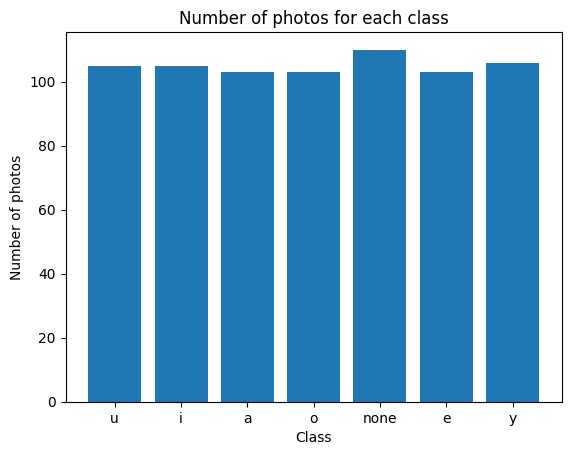

In [7]:
plt.bar(n_images.keys(), n_images.values())
plt.title("Number of photos for each class")
plt.ylabel("Number of photos")
plt.xlabel("Class")

In [8]:
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_embedding(image_path):
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0)
    with torch.no_grad():
        embedding = model(img_t).numpy()
    return embedding.flatten()


class_vectors = []

for unique_class in unique_classes:
	class_dir = os.path.join(dataset_dir, unique_class)
	n_images[unique_class] = len(os.listdir(class_dir))

	class_vector = []
	for img in tqdm(sorted(os.listdir(class_dir))):
		embedding = get_embedding(os.path.join(class_dir, img))
		class_vector.append(embedding)
		
	class_vectors.append(class_vector)

/Users/jakub/active/zpd/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jakub/active/zpd/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 106/106 [00:01<00:00, 58.06it/s]


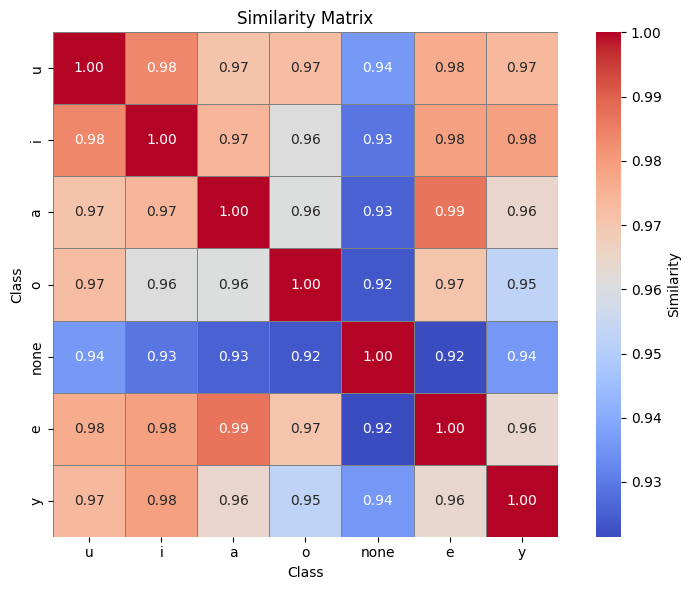

In [13]:
similarity_matrix = np.zeros((len(unique_classes), len(unique_classes)), dtype=np.float32)

for i, _ in enumerate(unique_classes):
	for j, _ in enumerate(unique_classes):
		centroid_A = np.mean(class_vectors[i], axis=0).reshape(1, -1)
		centroid_B = np.mean(class_vectors[j], axis=0).reshape(1, -1)

		similarity = cosine_similarity(centroid_A, centroid_B)[0][0]
		similarity_matrix[i, j] = similarity


plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, 
			xticklabels=unique_classes,
			yticklabels=unique_classes,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar_kws={'label': 'Similarity'},
            square=True,
            linewidths=0.5,
            linecolor='gray')
plt.title('Similarity Matrix')
plt.xlabel('Class')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

In [18]:
embeddings_flatten = []
labels = []
image_names = []

for class_idx, class_embedding in enumerate(class_vectors):
    class_name = unique_classes[class_idx]
    class_dir = os.path.join(dataset_dir, class_name)
    image_files = sorted(os.listdir(class_dir))
    
    embeddings_flatten.extend(class_embedding)
    labels.extend([class_idx] * len(class_embedding))
    image_names.extend(image_files)
    
embeddings_flatten = np.array(embeddings_flatten)
labels = np.array(labels)

In [19]:
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=20).fit_transform(embeddings_flatten)

In [20]:
fig = go.Figure()

for i, class_name in enumerate(unique_classes):
    mask = labels == i
    fig.add_trace(go.Scatter(
        x=X_embedded[mask, 0],
        y=X_embedded[mask, 1],
        mode='markers',
        name=class_name,
        marker=dict(size=8, opacity=0.7),
        hovertemplate='<b>%{customdata}</b><br>Class: ' + class_name + '<extra></extra>',
        customdata=np.array(image_names)[mask]
    ))

fig.update_layout(
    title='t-SNE Visualization of Image Embeddings by Class',
    xaxis_title='t-SNE Component 1',
    yaxis_title='t-SNE Component 2',
    hovermode='closest',
    width=1000,
    height=800,
    showlegend=True
)

fig.show()